In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\Data -Analyst\Projects\3. Global E-Commerce Sales & Customer Intelligence Analysis\ecommerce_sales_analysis_clean.csv")
df

,Order_ID,Order_Date,Customer_ID,Customer_Age,Customer_Gender,Region,Country,Category,Product_Name,Price,Quantity,Discount,Revenue,Profit,Payment_Method,Unnamed: 15
0,O00001,25-04-2023,C0052,65,Female,South,UK,Furniture,Desk,679.93,5.0,0.03,3297.66,677.60,Credit Card,NaN
1,O00002,06-04-2023,C0448,32,Male,South,Australia,Office Supplies,Pen Set,454.72,3.0,0.24,1036.76,105.36,Debit Card,NaN
2,O00003,08-03-2024,C0697,35,Male,South,India,Electronics,Laptop,386.13,3.0,0.25,868.79,218.01,Credit Card,NaN
3,O00004,15-04-2024,C1099,25,Female,North,Canada,Clothing,Jacket,581.58,1.0,0.01,575.76,90.38,PayPal,NaN
4,O00005,23-03-2023,C1752,32,Male,West,India,Office Supplies,Printer Paper,171.03,3.0,0.06,482.30,80.42,Credit Card,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,O07996,29-03-2023,C1011,43,Female,East,Australia,Clothing,T-Shirt,454.96,4.0,0.11,1619.66,218.38,Credit Card,NaN
7996,O07997,13-03-2024,C0682,52,Female,East,Germany,Electronics,Smartphone,434.34,1.0,0.23,334.44,79.22,PayPal,NaN
7997,O07998,01-05-2024,C1636,35,Male,West,Canada,Clothing,Shoes,938.96,1.0,0.11,835.67,240.60,Cash,NaN
7998,O07999,23-08-2023,C0690,63,Female,North,India,Furniture,Desk,319.76,5.0,0.13,1390.96,471.85,Cash,NaN


In [4]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Age,Customer_Gender,Region,Country,Category,Product_Name,Price,Quantity,Discount,Revenue,Profit,Payment_Method,Unnamed: 15
0,O00001,25-04-2023,C0052,65,Female,South,UK,Furniture,Desk,679.93,5.0,0.03,3297.66,677.60,Credit Card,NaN
1,O00002,06-04-2023,C0448,32,Male,South,Australia,Office Supplies,Pen Set,454.72,3.0,0.24,1036.76,105.36,Debit Card,NaN
2,O00003,08-03-2024,C0697,35,Male,South,India,Electronics,Laptop,386.13,3.0,0.25,868.79,218.01,Credit Card,NaN
3,O00004,15-04-2024,C1099,25,Female,North,Canada,Clothing,Jacket,581.58,1.0,0.01,575.76,90.38,PayPal,NaN
4,O00005,23-03-2023,C1752,32,Male,West,India,Office Supplies,Printer Paper,171.03,3.0,0.06,482.30,80.42,Credit Card,NaN


In [19]:
df = df.drop(columns=["Unnamed: 15"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         8000 non-null   object        
 1   Order_Date       8000 non-null   datetime64[ns]
 2   Customer_ID      8000 non-null   object        
 3   Customer_Age     8000 non-null   int64         
 4   Customer_Gender  8000 non-null   object        
 5   Region           8000 non-null   object        
 6   Country          8000 non-null   object        
 7   Category         8000 non-null   object        
 8   Product_Name     8000 non-null   object        
 9   Price            8000 non-null   float64       
 10  Quantity         8000 non-null   float64       
 11  Discount         8000 non-null   float64       
 12  Revenue          8000 non-null   float64       
 13  Profit           8000 non-null   float64       
 14  Payment_Method   8000 non-null   object 

In [21]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
Customer_Age       0
Customer_Gender    0
Region             0
Country            0
Category           0
Product_Name       0
Price              0
Quantity           0
Discount           0
Revenue            0
Profit             0
Payment_Method     0
Month              0
dtype: int64

In [7]:
df.describe()

,Customer_Age,Price,Quantity,Discount,Revenue,Profit,Unnamed: 15
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,0.0
mean,41.79625,501.504852,3.000625,0.149486,1279.062501,288.853083,NaN
std,13.85932,285.315596,1.413373,0.086822,1019.735291,258.061007,NaN
min,18.00000,10.050000,1.000000,0.000000,7.510000,1.370000,NaN
25%,30.00000,256.902500,2.000000,0.070000,468.872500,94.232500,NaN
50%,42.00000,496.730000,3.000000,0.150000,985.475000,208.835000,NaN
75%,54.00000,753.705000,4.000000,0.220000,1880.465000,411.372500,NaN
max,65.00000,999.970000,5.000000,0.300000,4907.230000,1712.480000,NaN


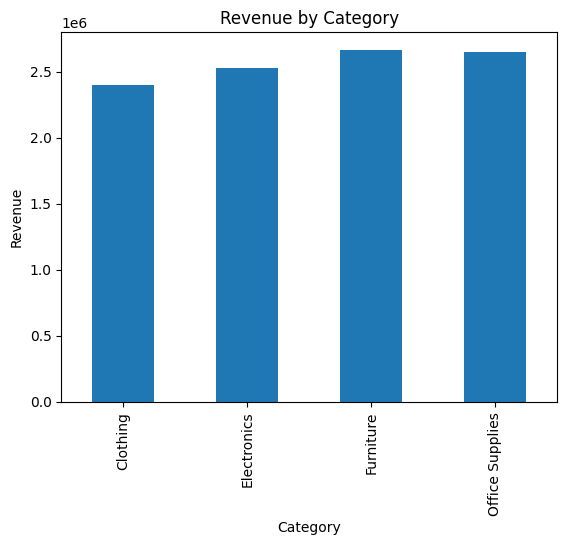

In [8]:
category_sales = df.groupby("Category")["Revenue"].sum()

category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

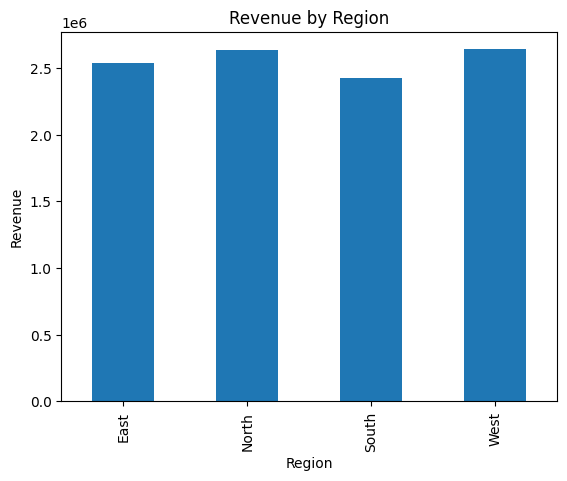

In [9]:
region_sales = df.groupby("Region")["Revenue"].sum()

region_sales.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

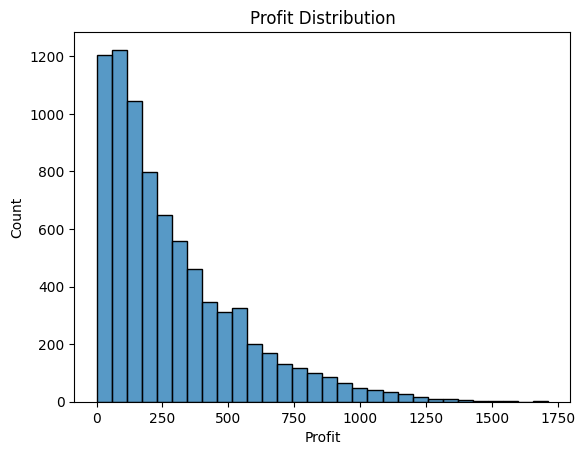

In [10]:
sns.histplot(df["Profit"], bins=30)
plt.title("Profit Distribution")
plt.show()

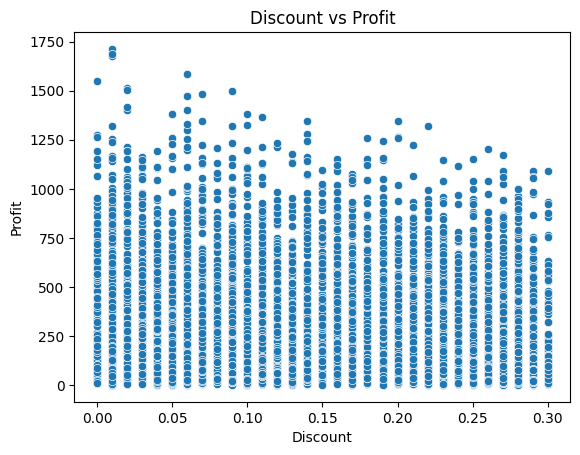

In [11]:
sns.scatterplot(x=df["Discount"], y=df["Profit"])
plt.title("Discount vs Profit")
plt.show()

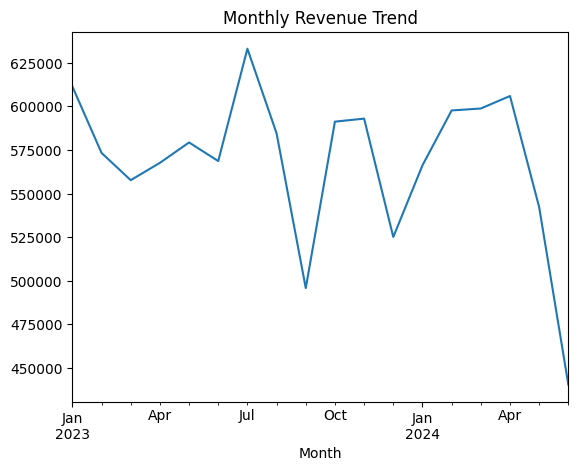

In [18]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Month"] = df["Order_Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Revenue"].sum()
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()

In [22]:
df.to_csv("ecommerce_cleaned.csv", index=False)